In [1]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
import yfinance as yf
import datetime
import math as m
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# ======================================================================
# Equilibrium Quant Portfolio
# ======================================================================
# Author    : Kesidis Angelos
# Assets    : IONQ, BE, SPIR, PSIX, BLBD (Growth/Thematic)
#             KO, JNJ, DUK, WMT, VZ      (Defensive)
# Benchmark : S&P 500 (^GSPC)
# Period    : 2023-01-01 to Today
# ======================================================================

# Data Collection

In [3]:
# ======================================================================
# SECTION 1 — Data Collection
# ======================================================================

growth    = ["IONQ", "BE", "SPIR", "PSIX", "BLBD"]
defensive = ["KO", "JNJ", "DUK", "WMT", "VZ"]
 
stocks  = growth + defensive                   # 10 assets
tickers = stocks + ["^GSPC"]                   # + benchmark

data = yf.download(tickers, start="2023-01-01")["Close"]
 
print("Shape :", data.shape)
print("Columns :", list(data.columns))
print("\nFirst rows :")
print(data.head())
print("\nLast rows :")
print(data.tail())
print("\nMissing values per column :")
print(data.isnull().sum())

[*********************100%***********************]  11 of 11 completed

Shape : (840, 11)
Columns : ['BE', 'BLBD', 'DUK', 'IONQ', 'JNJ', 'KO', 'PSIX', 'SPIR', 'VZ', 'WMT', '^GSPC']

First rows :
Ticker             BE   BLBD        DUK  IONQ         JNJ         KO  PSIX  \
Date                                                                         
2023-01-03  19.190001  11.57  91.319145  3.46  161.795761  57.126350  3.01   
2023-01-04  20.120001  12.01  92.296638  3.61  163.557266  57.099117  3.01   
2023-01-05  19.160000  12.44  90.931686  3.64  162.349640  56.445736  3.00   
2023-01-06  19.030001  13.10  92.622444  3.77  163.666229  57.534725  3.00   
2023-01-09  19.889999  13.88  92.631256  3.81  159.425873  56.817806  3.01   

Ticker       SPIR         VZ        WMT        ^GSPC  
Date                                                  
2023-01-03  8.000  31.746319  45.965157  3824.139893  
2023-01-04  8.240  32.545525  46.016361  3852.969971  
2023-01-05  7.536  32.996552  45.859520  3808.100098  
2023-01-06  7.880  33.384277  46.983044  3895.080078  


# Normalization & Price Performance

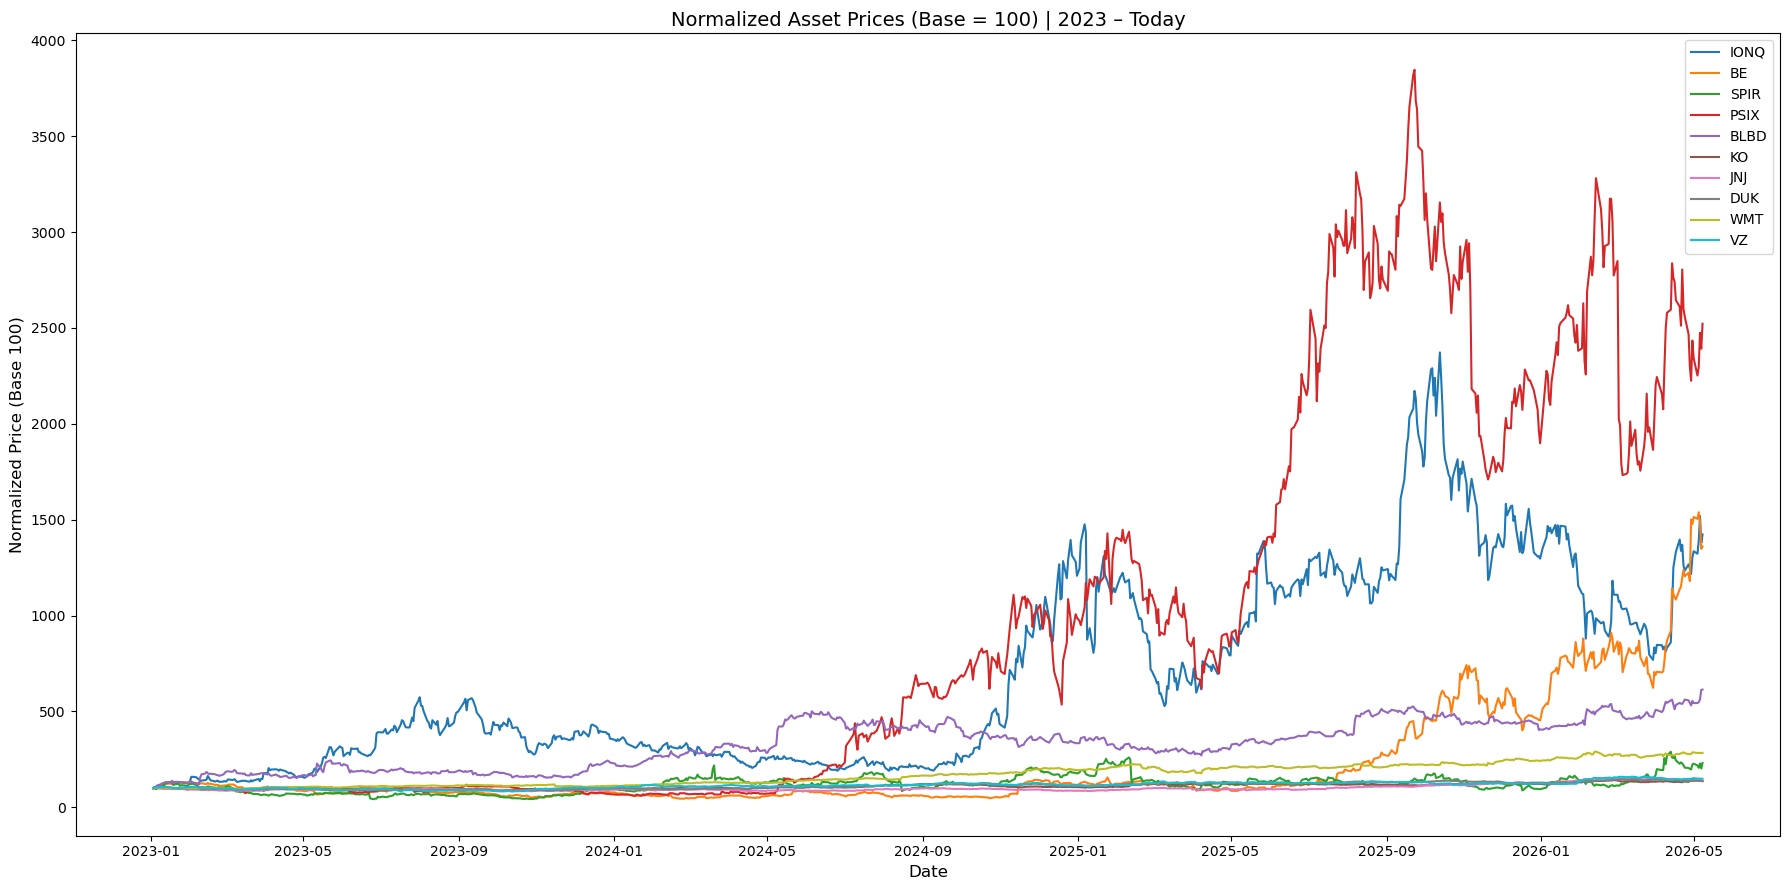

In [4]:
# ======================================================================
# SECTION 2 — Normalization & Price Performance
# ======================================================================
 
normalization = (data[stocks] / data[stocks].iloc[0]) * 100
 
plt.figure(figsize=(18, 9))
for col in normalization.columns:
    plt.plot(normalization[col], label=col)
 
plt.title("Normalized Asset Prices (Base = 100) | 2023 – Today", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend(stocks)
plt.tight_layout()
plt.show()

# Log Returns

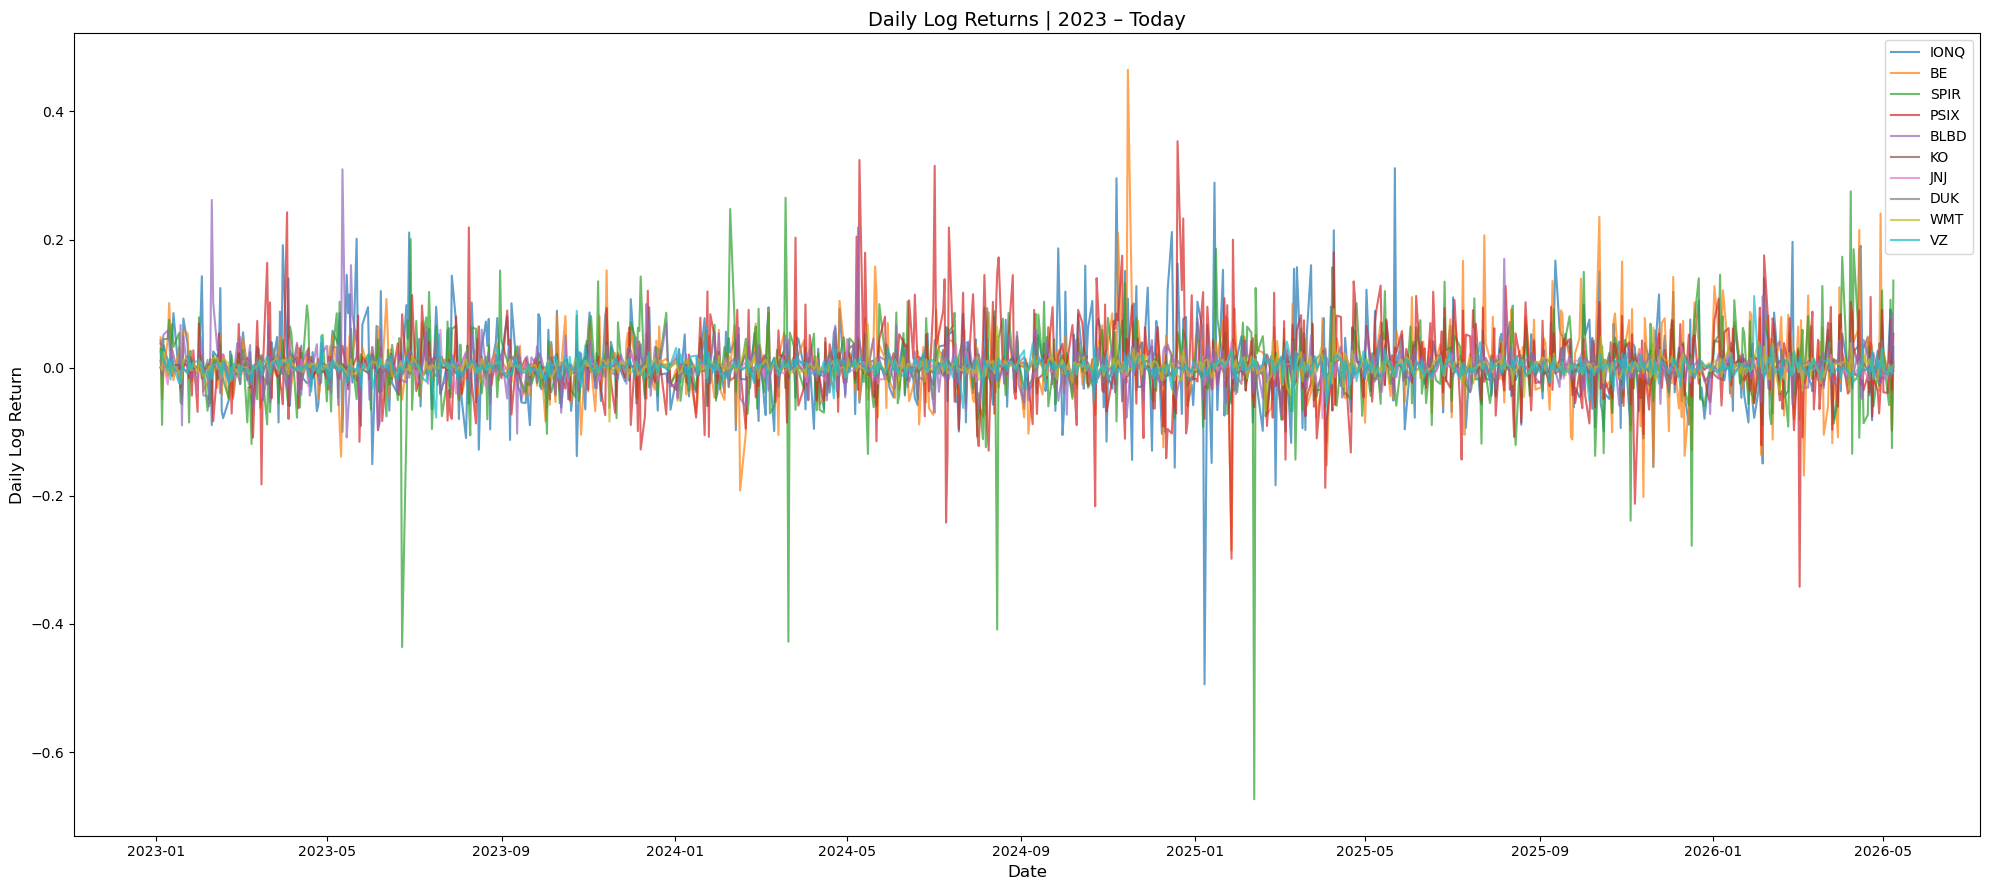

In [5]:
# ======================================================================
# SECTION 3 — Log Returns
# ======================================================================
 
log_return = np.log(data / data.shift(1))
 
plt.figure(figsize=(20, 9))
for col in stocks:
    plt.plot(log_return[col], label=col, alpha=0.7)
 
plt.title("Daily Log Returns | 2023 – Today", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Log Return", fontsize=12)
plt.legend(stocks)
plt.tight_layout()
plt.show()

# Individual Asset Risk & Return

In [6]:
# ======================================================================
# SECTION 4 — Individual Asset Risk & Return
# ======================================================================
 
annual_return   = log_return[stocks].mean() * 250
annual_variance = log_return[stocks].var()  * 250
annual_std      = log_return[stocks].std()  * (250 ** 0.5)
 
rf = 0.043  # Risk-free rate: US 10-Year Treasury (2025-2026)
sharpe_ratio = (annual_return - rf) / annual_std
 
summary_individual = pd.DataFrame({
    "Annual Return (%)":    (annual_return   * 100).round(2),
    "Annual Variance":       annual_variance.round(6),
    "Volatility / Risk (%)": (annual_std      * 100).round(2),
    "Sharpe Ratio":          sharpe_ratio.round(3)
})
 
print("\n===== Individual Asset Risk & Return Summary =====")
print(summary_individual.to_string())


===== Individual Asset Risk & Return Summary =====
        Annual Return (%)  Annual Variance  Volatility / Risk (%)  Sharpe Ratio
Ticker                                                                         
IONQ                79.13         0.979678                  98.98         0.756
BE                  77.78         0.727708                  85.31         0.861
SPIR                24.96         1.016230                 100.81         0.205
PSIX                96.17         0.999242                  99.96         0.919
BLBD                54.07         0.282770                  53.18         0.936
KO                   9.44         0.022520                  15.01         0.343
JNJ                  9.33         0.029149                  17.07         0.295
DUK                  9.16         0.028526                  16.89         0.288
WMT                 31.08         0.041418                  20.35         1.316
VZ                  11.83         0.049860                  22.33   

# Efficient Frontier (Monte Carlo Simulation)

In [7]:
# ======================================================================
# SECTION 5 — Efficient Frontier (Monte Carlo Simulation)
# ======================================================================
 
cov_matrix_annual = log_return[stocks].cov() * 250
num_assets = len(stocks)
 
portfolio_returns      = []
portfolio_volatilities = []
portfolio_weights_list = []
 
for _ in range(10000):
    weights  = np.random.random(num_assets)
    weights /= np.sum(weights)                     # constraint: Σwᵢ = 1
 
    p_ret = np.sum(weights * log_return[stocks].mean() * 250)
    p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_annual, weights)))
 
    portfolio_returns.append(p_ret)
    portfolio_volatilities.append(p_vol)
    portfolio_weights_list.append(weights)
 
portfolio_returns      = np.array(portfolio_returns)
portfolio_volatilities = np.array(portfolio_volatilities)
 
print("\nMax Return    :", round(portfolio_returns.max()      * 100, 2), "%")
print("Min Volatility:", round(portfolio_volatilities.min() * 100, 2), "%")
 
portfolios = pd.DataFrame({
    "Return":     portfolio_returns,
    "Volatility": portfolio_volatilities
})
 

min_var_idx = portfolios["Volatility"].idxmin()
max_ret_idx = portfolios["Return"].idxmax()
 
MVP = portfolios.loc[min_var_idx]
MRP = portfolios.loc[max_ret_idx]
 

best_weights_MVP = portfolio_weights_list[min_var_idx]
best_weights_MRP = portfolio_weights_list[max_ret_idx]
 
print("\nMinimum Variance Portfolio:")
print(round(MVP * 100, 2))
print("\nMaximum Return Portfolio:")
print(round(MRP * 100, 2))


Max Return    : 67.96 %
Min Volatility: 12.44 %

Minimum Variance Portfolio:
Return        21.54
Volatility    12.44
Name: 3401, dtype: float64

Maximum Return Portfolio:
Return        67.96
Volatility    48.62
Name: 6359, dtype: float64


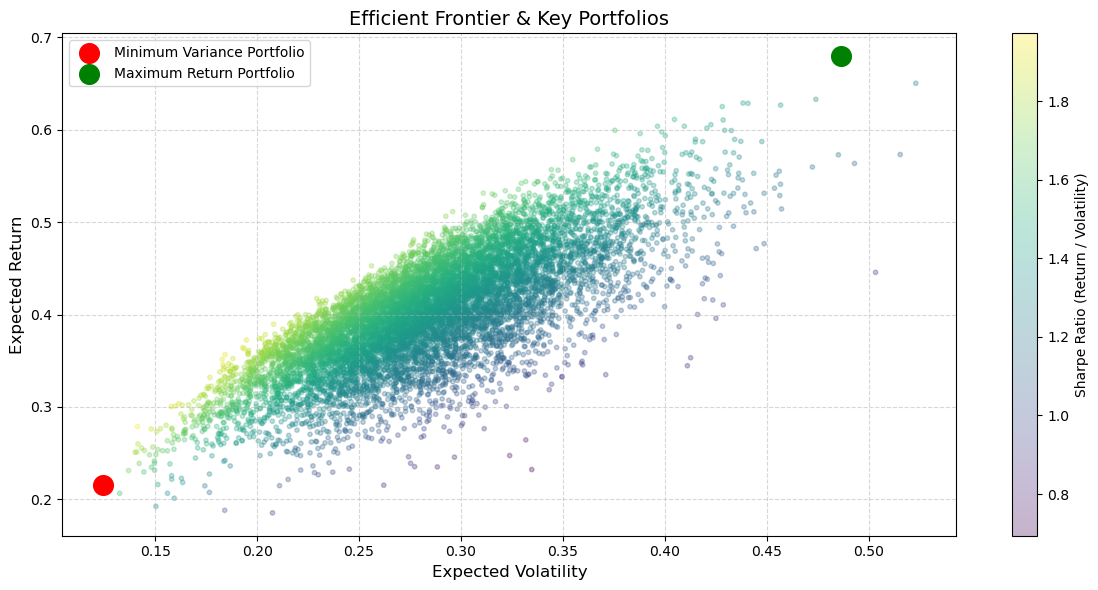

In [8]:
# --- Plot Efficient Frontier ---

plt.figure(figsize=(12, 6))
 
sc = plt.scatter(
    portfolios["Volatility"], portfolios["Return"],
    c=portfolios["Return"] / portfolios["Volatility"],
    marker='o', s=10, alpha=0.3, cmap='viridis'
)
 
plt.scatter(MVP["Volatility"], MVP["Return"],
            color='red', marker='o', s=200, zorder=5,
            label="Minimum Variance Portfolio")
 
plt.scatter(MRP["Volatility"], MRP["Return"],
            color='green', marker='o', s=200, zorder=5,
            label="Maximum Return Portfolio")
 
plt.title("Efficient Frontier & Key Portfolios", fontsize=14)
plt.xlabel("Expected Volatility", fontsize=12)
plt.ylabel("Expected Return", fontsize=12)
plt.legend()
plt.colorbar(sc, label='Sharpe Ratio (Return / Volatility)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Portfolio Construction & Comparison

In [9]:
# ======================================================================
# SECTION 6 — Portfolio Construction & Comparison
# ======================================================================
 
my_weights = np.array([1 / num_assets] * num_assets)
 
my_ret = np.sum(my_weights * log_return[stocks].mean() * 250)
my_vol = np.sqrt(np.dot(my_weights.T, np.dot(cov_matrix_annual, my_weights)))
 
portfolio_return   = my_ret
portfolio_variance = np.dot(my_weights.T, np.dot(cov_matrix_annual, my_weights))  # FIX #3
portfolio_volatility = portfolio_variance ** 0.5
 
print(f"\n--- My Equal-Weight Portfolio ---")
print(f"Return    : {round(my_ret * 100, 2)}%")
print(f"Volatility: {round(my_vol * 100, 2)}%")
print(f"Sharpe    : {round((my_ret - rf) / my_vol, 3)}")
 
print(f"\n--- Optimized Portfolios (From Simulation) ---")
print(f"MVP Return: {round(MVP['Return'] * 100, 2)}% | Volatility: {round(MVP['Volatility'] * 100, 2)}%")
print(f"MRP Return: {round(MRP['Return'] * 100, 2)}% | Volatility: {round(MRP['Volatility'] * 100, 2)}%")


--- My Equal-Weight Portfolio ---
Return    : 40.29%
Volatility: 26.66%
Sharpe    : 1.35

--- Optimized Portfolios (From Simulation) ---
MVP Return: 21.54% | Volatility: 12.44%
MRP Return: 67.96% | Volatility: 48.62%



===== Optimal Weights Assignment =====
  Asset  MVP_Weight  MRP_Weight
8   WMT       20.11        3.10
7   DUK       19.63        2.25
5    KO       18.25        3.23
9    VZ       18.20        1.79
6   JNJ        9.71        0.35
4  BLBD        8.93       19.43
3  PSIX        2.56       24.47
2  SPIR        1.18        6.54
0  IONQ        0.94       26.46
1    BE        0.51       12.40


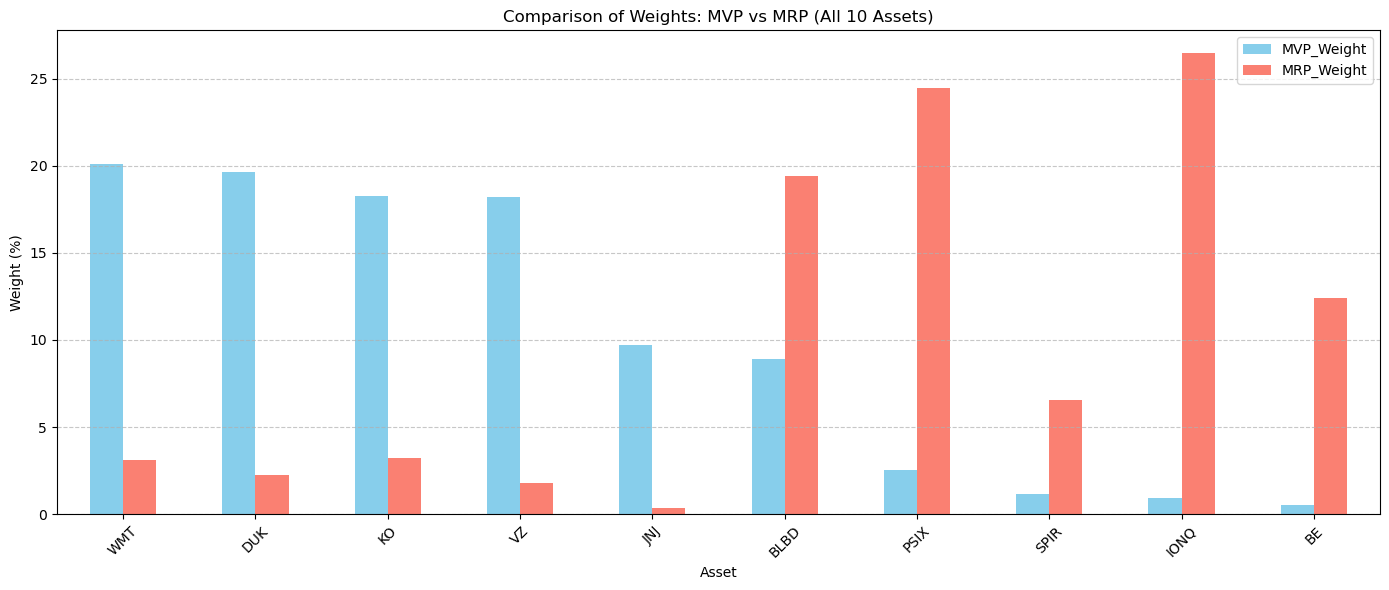

In [10]:
# --- Weights Comparison Table ---

weights_df = pd.DataFrame({
    'Asset':      stocks,
    'MVP_Weight': (best_weights_MVP * 100).round(2),
    'MRP_Weight': (best_weights_MRP * 100).round(2)
})
 
print("\n===== Optimal Weights Assignment =====")
print(weights_df.sort_values(by="MVP_Weight", ascending=False))
 
weights_df.set_index('Asset').sort_values(by="MVP_Weight", ascending=False).plot(
    kind='bar', figsize=(14, 6), color=['skyblue', 'salmon']
)
plt.title("Comparison of Weights: MVP vs MRP (All 10 Assets)")
plt.ylabel("Weight (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Covariance & Correlation Analysis

In [11]:
# ======================================================================
# SECTION 7 — Covariance & Correlation Analysis
# ======================================================================

# --- Covariance Matrix (annualized) ---
annual_covariance = log_return[stocks].cov() * 250
 
print("\n===== Annual Covariance Matrix =====")
print(annual_covariance.round(6))
 
# --- Correlation Matrix (ΠΟΤΕ * 250 — dimensionless) ---
correlation_matrix = log_return[stocks].corr()
 
print("\n===== Correlation Matrix =====")
print(correlation_matrix.round(3))
print("\nDiagonal check (must all be 1.0):", np.diag(correlation_matrix.values).round(3))


===== Annual Covariance Matrix =====
Ticker      IONQ        BE      SPIR      PSIX      BLBD        KO       JNJ  \
Ticker                                                                         
IONQ    0.979678  0.280706  0.248040  0.167570  0.059193 -0.017078 -0.006706   
BE      0.280706  0.727708  0.191655  0.191507  0.064044 -0.006220 -0.003349   
SPIR    0.248040  0.191655  1.016230  0.084791  0.089900 -0.002441 -0.004880   
PSIX    0.167570  0.191507  0.084791  0.999242  0.046263 -0.012056 -0.010460   
BLBD    0.059193  0.064044  0.089900  0.046263  0.282770  0.002606 -0.002608   
KO     -0.017078 -0.006220 -0.002441 -0.012056  0.002606  0.022520  0.010428   
JNJ    -0.006706 -0.003349 -0.004880 -0.010460 -0.002608  0.010428  0.029149   
DUK    -0.011304  0.003949 -0.000510 -0.013163 -0.001290  0.012719  0.012284   
WMT     0.018364  0.008413 -0.002719  0.020721  0.011707  0.009499  0.006855   
VZ     -0.013464  0.005127 -0.000179 -0.024542  0.002958  0.011640  0.009928   

T

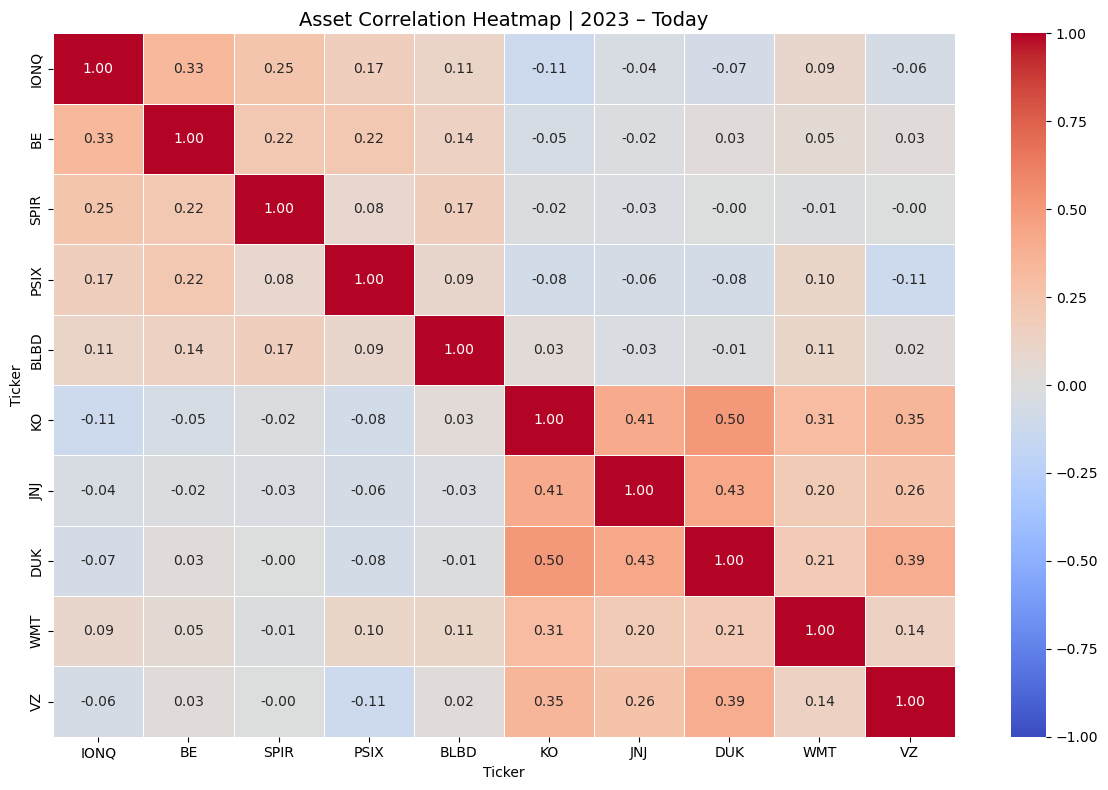

In [12]:
# --- Heatmap ---

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Asset Correlation Heatmap | 2023 – Today", fontsize=14)
plt.tight_layout()
plt.show()

# Portfolio Variance & Risk Decomposition

In [13]:
# ======================================================================
# SECTION 8 — Portfolio Variance & Risk Decomposition
# ======================================================================
 
print("\n===== Portfolio Variance & Volatility =====")
print(f"Variance  : {portfolio_variance:.6f}")
print(f"Volatility: {round(portfolio_volatility * 100, 2)}%")
 
# --- Systematic vs Diversifiable Risk ---
def weighted_individual_variance(weights, variances):
    """Σwᵢ² * σᵢ² — variance if all assets were perfectly uncorrelated."""
    return np.sum(weights**2 * variances)

variances_array    = annual_variance[stocks].values
wiv                = weighted_individual_variance(my_weights, variances_array)
diversifiable_risk = wiv - portfolio_variance      # removed by diversification
systematic_risk    = portfolio_variance            # cannot be removed (lower bound)
 
print("\n===== Risk Decomposition =====")
print(f"Total Portfolio Variance : {portfolio_variance:.6f}")
print(f"Systematic Risk          : {systematic_risk:.6f}   (cannot be diversified away)")
print(f"Diversifiable Risk       : {diversifiable_risk:.6f}   (eliminated via diversification)")


===== Portfolio Variance & Volatility =====
Variance  : 0.071096
Volatility: 26.66%

===== Risk Decomposition =====
Total Portfolio Variance : 0.071096
Systematic Risk          : 0.071096   (cannot be diversified away)
Diversifiable Risk       : -0.029325   (eliminated via diversification)


# Regression Analysis: Each Stock vs S&P 500

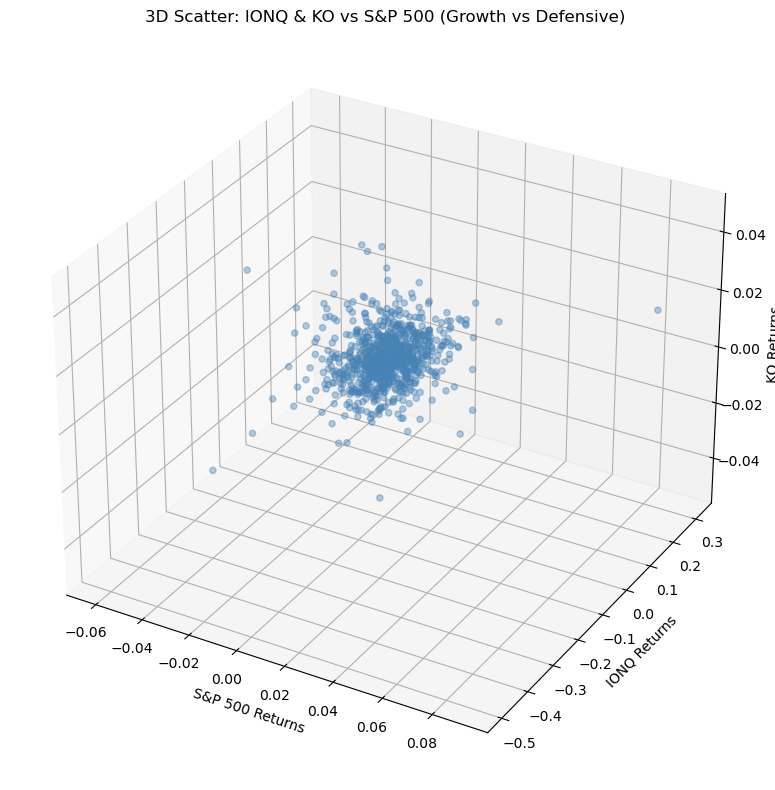

In [14]:
# ======================================================================
# SECTION 9 — Regression Analysis: Each Stock vs S&P 500
# ======================================================================
 
clean_data = log_return.dropna()
 
# --- 3D Scatter: IONQ & KO vs Market ---
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(
    clean_data["^GSPC"],
    clean_data["IONQ"],
    clean_data["KO"],
    c="steelblue", marker="o", alpha=0.4
)
ax.set_xlabel("S&P 500 Returns")
ax.set_ylabel("IONQ Returns")
ax.set_zlabel("KO Returns")
ax.set_title("3D Scatter: IONQ & KO vs S&P 500 (Growth vs Defensive)")
plt.tight_layout()
plt.show()

In [15]:
# --- OLS Regressions ---

X_market = sm.add_constant(clean_data["^GSPC"])
 
regression_results = {}
 
for stock in stocks:
    Y     = clean_data[stock]
    model = sm.OLS(Y, X_market).fit()
    regression_results[stock] = {
        "Beta"   : model.params["^GSPC"],
        "Alpha"  : model.params["const"],
        "R²"     : model.rsquared,
        "p-value": model.pvalues["^GSPC"]
    }
    print(f"\n{'='*50}")
    print(f"Model: {stock} vs S&P 500")
    print(f"{'='*50}")
    print(model.summary())


Model: IONQ vs S&P 500
                            OLS Regression Results                            
Dep. Variable:                   IONQ   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     187.2
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.34e-38
Time:                        13:58:31   Log-Likelihood:                 1219.5
No. Observations:                 839   AIC:                            -2435.
Df Residuals:                     837   BIC:                            -2426.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0

# Final Summary Dashboard

In [16]:
# ======================================================================
# SECTION 10 — Final Summary Dashboard
# ======================================================================
 
# --- Individual Asset Summary ---
print("\n\n" + "="*60)
print("       INDIVIDUAL ASSET RISK & RETURN SUMMARY")
print("="*60)
print(summary_individual.to_string())
 
# --- Beta & Regression Summary ---
beta_summary = pd.DataFrame(regression_results).T
beta_summary["Beta"]    = beta_summary["Beta"].round(3)
beta_summary["Alpha"]   = beta_summary["Alpha"].round(6)
beta_summary["R²"]      = beta_summary["R²"].round(3)
beta_summary["p-value"] = beta_summary["p-value"].apply(lambda x: f"{x:.2e}")
 
print("\n" + "="*60)
print("       BETA & REGRESSION SUMMARY (vs S&P 500)")
print("="*60)
print(beta_summary.to_string())



       INDIVIDUAL ASSET RISK & RETURN SUMMARY
        Annual Return (%)  Annual Variance  Volatility / Risk (%)  Sharpe Ratio
Ticker                                                                         
IONQ                79.13         0.979678                  98.98         0.756
BE                  77.78         0.727708                  85.31         0.861
SPIR                24.96         1.016230                 100.81         0.205
PSIX                96.17         0.999242                  99.96         0.919
BLBD                54.07         0.282770                  53.18         0.936
KO                   9.44         0.022520                  15.01         0.343
JNJ                  9.33         0.029149                  17.07         0.295
DUK                  9.16         0.028526                  16.89         0.288
WMT                 31.08         0.041418                  20.35         1.316
VZ                  11.83         0.049860                  22.33       

# Portfolio-Level Summary 

In [17]:
# --- Portfolio-Level Summary ---

summary_portfolio = pd.DataFrame({
    "Annual Return (%)":   [round(portfolio_return     * 100, 2)],
    "Volatility (%)":      [round(portfolio_volatility * 100, 2)],
    "Sharpe Ratio":        [round((portfolio_return - rf) / portfolio_volatility, 3)],
    "Variance":            [round(portfolio_variance,          6)],
    "Systematic Risk":     [round(systematic_risk,             6)],
    "Diversifiable Risk":  [round(diversifiable_risk,          6)]
}, index=["Portfolio (Equal Weight — 10 Assets)"])
 
print("\n" + "="*60)
print("       FINAL PORTFOLIO SUMMARY")
print("="*60)
print(summary_portfolio.to_string())
 
print("\n Analysis complete — Equilibrium Quant Portfolio | Kesidis Angelos")


       FINAL PORTFOLIO SUMMARY
                                      Annual Return (%)  Volatility (%)  Sharpe Ratio  Variance  Systematic Risk  Diversifiable Risk
Portfolio (Equal Weight — 10 Assets)              40.29           26.66          1.35  0.071096         0.071096           -0.029325

 Analysis complete — Equilibrium Quant Portfolio | Kesidis Angelos
